# Validación del horizonte `HORIZON_CHURN` en escala mensual (v4)

Replica el Bloque 2 del NB 01 (`elección de la ventana k`) en la granularidad
mensual de v4, para responder:

> **¿`HORIZON_CHURN = 4` meses es la mejor ventana, o conviene otro valor?**

Decisión heredada de `qry_churn_v4.sql` (header):
> "4 meses sin compra es señal robusta de pérdida; 6 meses sería tarde para
> retención. La elección está abierta a revisión."

Análisis (espejo del NB 01 pero en meses):

1. Panel de eventos `(id_vendedor, mes)` con la misma limpieza que v4
   (blacklist 20102, 20201, 23105).
2. Distribución de gaps entre compras consecutivas (CDF y modas).
3. Curva silent vs k=1..12 sobre sub-muestra fully-observable + hazard.
4. Sensibilidad: para k ∈ [2..8], churn rate, n y Cohen's kappa vs k=4.
5. Codo automático.
6. Cohortes pre-2025 vs post-2025 (régimen 1 campaña/mes vs 2-3) para
   detectar si el horizonte óptimo cambió.
7. Síntesis y recomendación.

Filtro de población: `cum_purchases >= 3`, consistente con
`compras_historicas >= 3` en v4.


## 1. Setup y carga del panel de eventos


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery
from sklearn.metrics import cohen_kappa_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

PROJECT, DATASET = 'glamour-peru-dw', 'glamour_dw'
BLACKLIST = (20102, 20201, 23105)

bq = bigquery.Client(project=PROJECT)


In [2]:
QUERY_EVENTS = f"""
WITH
  rango_fechas AS (
    SELECT
      DATE_TRUNC(MIN(d.date), MONTH) AS primer_mes,
      DATE_TRUNC(MAX(d.date), MONTH) AS ultimo_mes
    FROM `{PROJECT}.{DATASET}.fact_pedidos` p
    JOIN `{PROJECT}.{DATASET}.dim_fecha` d ON p.id_fecha = d.id_fecha
  ),
  meses_ordenados AS (
    SELECT
      mes,
      ROW_NUMBER() OVER (ORDER BY mes) AS mes_rank
    FROM rango_fechas,
    UNNEST(GENERATE_DATE_ARRAY(primer_mes, ultimo_mes, INTERVAL 1 MONTH)) AS mes
  ),
  pedidos_limpios AS (
    SELECT
      p.id_vendedor,
      DATE_TRUNC(d.date, MONTH) AS mes
    FROM `{PROJECT}.{DATASET}.fact_pedidos` p
    JOIN `{PROJECT}.{DATASET}.dim_fecha` d ON p.id_fecha = d.id_fecha
    WHERE p.id_campana NOT IN {BLACKLIST}
  )
SELECT DISTINCT
  pl.id_vendedor,
  pl.mes,
  m.mes_rank
FROM pedidos_limpios pl
JOIN meses_ordenados m ON pl.mes = m.mes
ORDER BY pl.id_vendedor, m.mes_rank
"""

events = bq.query(QUERY_EVENTS).to_dataframe()
events['mes'] = pd.to_datetime(events['mes'])

events['cum_purchases'] = events.groupby('id_vendedor').cumcount() + 1
events['next_rank']     = events.groupby('id_vendedor')['mes_rank'].shift(-1)
events['gap_to_next']   = events['next_rank'] - events['mes_rank']

LAST_RANK = int(events['mes_rank'].max())
events['observable_horizon'] = LAST_RANK - events['mes_rank']

print(f'Eventos (vendedora, mes)   : {len(events):,}')
print(f'Vendedoras únicas          : {events["id_vendedor"].nunique():,}')
print(f'Rango de meses             : {events["mes"].min().date()} → {events["mes"].max().date()}')
print(f'Último mes_rank observado  : {LAST_RANK}')
print(f'Compras promedio por vend. : {len(events) / events["id_vendedor"].nunique():.2f}')
events.head(10)


Eventos (vendedora, mes)   : 43,118
Vendedoras únicas          : 11,839
Rango de meses             : 2016-11-01 → 2026-04-01
Último mes_rank observado  : 114
Compras promedio por vend. : 3.64


,id_vendedor,mes,mes_rank,cum_purchases,next_rank,gap_to_next,observable_horizon
0,11061213,2023-08-01,82,1,105,23,32
1,11061213,2025-07-01,105,2,<NA>,<NA>,9
2,19721994,2016-12-01,2,1,3,1,112
3,19721994,2017-01-01,3,2,4,1,111
4,19721994,2017-02-01,4,3,6,2,110
5,19721994,2017-04-01,6,4,7,1,108
6,19721994,2017-05-01,7,5,11,4,107
7,19721994,2017-09-01,11,6,19,8,103
8,19721994,2018-05-01,19,7,25,6,95
9,19721994,2018-11-01,25,8,26,1,89


**Insight — Panel de eventos mensuales**

Equivalente al panel de NB 01 pero a granularidad mensual: una fila por mes
calendario en el que la vendedora tuvo al menos un pedido (excluyendo la
blacklist de campañas). `gap_to_next` mide la distancia (en meses) hasta la
siguiente compra; es el insumo central para definir churn. Las observaciones
con `observable_horizon < k` no son evaluables para esa k.


## 2. Distribución de gaps cerrados


Gaps cerrados (cum_purchases >= 3): 20,597

Percentiles del gap (meses):
count    20597.000000
mean         3.890712
std          7.271111
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
90%          9.000000
95%         15.000000
99%         38.000000
max        104.000000
Name: gap_to_next, dtype: float64

Distribución (k=1..15):
              freq    pct    cdf
gap_to_next                     
1            10192  49.48  49.48
2             3640  17.67  67.16
3             1710   8.30  75.46
4             1036   5.03  80.49
5              700   3.40  83.89
6              510   2.48  86.36
7              389   1.89  88.25
8              351   1.70  89.95
9              260   1.26  91.22
10             185   0.90  92.12
11             200   0.97  93.09
12             170   0.83  93.91
13             112   0.54  94.46
14              94   0.46  94.91
15              90   0.44  95.35


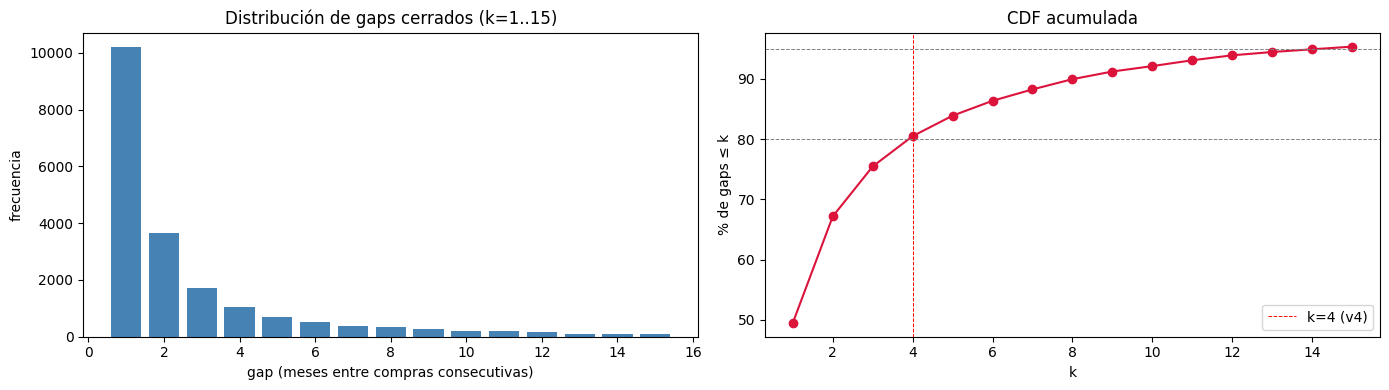

{'n_gaps': 20597,
 'p50': 2.0,
 'p75': 3.0,
 'p90': 9.0,
 'pct_ge_3': 0.32844589017818127,
 'pct_ge_4': 0.24542409088702238,
 'pct_ge_5': 0.19512550371413312,
 'pct_ge_6': 0.1611399718405593}

In [3]:
events_h3 = events[events['cum_purchases'] >= 3]
gaps = events_h3['gap_to_next'].dropna().astype(int)

print(f'Gaps cerrados (cum_purchases >= 3): {len(gaps):,}')
print('\nPercentiles del gap (meses):')
print(gaps.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

gap_freq = gaps.value_counts().sort_index()
gap_pct  = (gap_freq / len(gaps) * 100).round(2)
gap_cdf  = (gap_freq.cumsum() / len(gaps) * 100).round(2)
tabla_gaps = pd.DataFrame({'freq': gap_freq, 'pct': gap_pct, 'cdf': gap_cdf}).head(15)
print('\nDistribución (k=1..15):')
print(tabla_gaps)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(gap_freq.head(15).index, gap_freq.head(15).values, color='steelblue')
ax[0].set_xlabel('gap (meses entre compras consecutivas)')
ax[0].set_ylabel('frecuencia')
ax[0].set_title('Distribución de gaps cerrados (k=1..15)')

ax[1].plot(gap_cdf.head(15).index, gap_cdf.head(15).values, marker='o', color='crimson')
ax[1].axhline(80, ls='--', color='gray', lw=0.7)
ax[1].axhline(95, ls='--', color='gray', lw=0.7)
ax[1].axvline(4,  ls='--', color='red',  lw=0.7, label='k=4 (v4)')
ax[1].set_xlabel('k')
ax[1].set_ylabel('% de gaps ≤ k')
ax[1].set_title('CDF acumulada')
ax[1].legend()
plt.tight_layout()
plt.show()

GAP_STATS = {
    'n_gaps':       len(gaps),
    'p50':          float(gaps.quantile(0.5)),
    'p75':          float(gaps.quantile(0.75)),
    'p90':          float(gaps.quantile(0.9)),
    'pct_ge_3':     float((gaps >= 3).mean()),
    'pct_ge_4':     float((gaps >= 4).mean()),
    'pct_ge_5':     float((gaps >= 5).mean()),
    'pct_ge_6':     float((gaps >= 6).mean()),
}
GAP_STATS


**Insight — Distribución de gaps**

- Mediana, P75, P90 del gap mensual.
- `% gaps ≥ k` es la *cota inferior* de la tasa de falsos churn si se elige
  ese k (gaps que terminan en compra pero serían marcados como churn).
- Un k corto (3 meses) etiqueta como churn una porción significativa de
  vendedoras esporádicas-pero-vuelven; un k largo (≥6) reduce ese ruido pero
  retrasa la señal de retención.


## 3. Curva silent vs k + hazard


Sub-muestra fully-observable (>= 12 meses futuros): 22,642 (91.0% de events_h3)
     k  pct_silent  hazard
0    1      0.5863 -0.4137
1    2      0.4386  0.2519
2    3      0.3682  0.1605
3    4      0.3264  0.1136
4    5      0.2978  0.0876
5    6      0.2761  0.0730
6    7      0.2599  0.0586
7    8      0.2449  0.0576
8    9      0.2335  0.0465
9   10      0.2254  0.0350
10  11      0.2165  0.0392
11  12      0.2090  0.0347


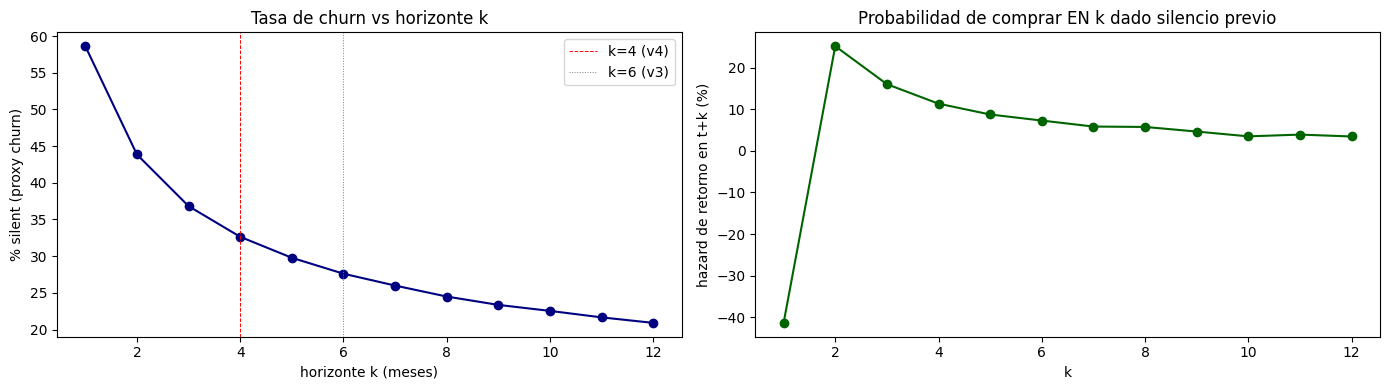

In [4]:
MAX_K = 12
subset = events_h3[events_h3['observable_horizon'] >= MAX_K].copy()
print(f'Sub-muestra fully-observable (>= {MAX_K} meses futuros): {len(subset):,} '
      f'({len(subset)/len(events_h3):.1%} de events_h3)')

rows = []
for k in range(1, MAX_K + 1):
    silent = (subset['gap_to_next'].isna() | (subset['gap_to_next'] > k)).mean()
    rows.append({'k': k, 'pct_silent': silent})
horizon_curve = pd.DataFrame(rows)

horizon_curve['hazard'] = (
    -horizon_curve['pct_silent'].diff().fillna(1 - horizon_curve['pct_silent'].iloc[0])
    / horizon_curve['pct_silent'].shift(1).fillna(1.0)
)
print(horizon_curve.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(horizon_curve['k'], horizon_curve['pct_silent'] * 100, marker='o', color='navy')
ax[0].axvline(4, ls='--', color='red', lw=0.7, label='k=4 (v4)')
ax[0].axvline(6, ls=':',  color='gray', lw=0.7, label='k=6 (v3)')
ax[0].set_xlabel('horizonte k (meses)')
ax[0].set_ylabel('% silent (proxy churn)')
ax[0].set_title('Tasa de churn vs horizonte k')
ax[0].legend()

ax[1].plot(horizon_curve['k'], horizon_curve['hazard'] * 100, marker='o', color='darkgreen')
ax[1].set_xlabel('k')
ax[1].set_ylabel('hazard de retorno en t+k (%)')
ax[1].set_title('Probabilidad de comprar EN k dado silencio previo')
plt.tight_layout()
plt.show()

HORIZON_CURVE = horizon_curve


**Insight — Curva silent y hazard**

- La curva `pct_silent` debe caer rápido en las primeras k y estabilizarse:
  donde aplane es donde la mayoría de las vendedoras ya volvió.
- El hazard mide la probabilidad condicional de retorno *exactamente* en t+k
  dado silencio previo. Picos al inicio = vendedoras "regulares"; cola larga
  = "esporádicas-pero-vuelven".
- Comparamos la posición de k=4 (v4) y k=6 (v3) sobre la curva.


## 4. Sensibilidad y kappa vs k=4


Sensibilidad por k:
   k  n_obs  n_vendedoras  churn_rate  positives
0  2  24546          4269       43.95      10789
1  3  24359          4261       36.93       8996
2  4  24178          4246       32.64       7892
3  5  23927          4229       29.67       7099
4  6  23703          4216       27.52       6522
5  7  23528          4205       25.91       6095
6  8  23346          4197       24.41       5699

Concordancia con churn (k=4):
   k  kappa_vs_ref  agree_pct  n_overlap
0  2        0.7632     0.8865      24178
1  3        0.9057     0.9572      24178
2  4        1.0000     1.0000      24178
3  5        0.9318     0.9707      23927
4  6        0.8794     0.9491      23703
5  7        0.8382     0.9326      23528
6  8        0.7995     0.9175      23346


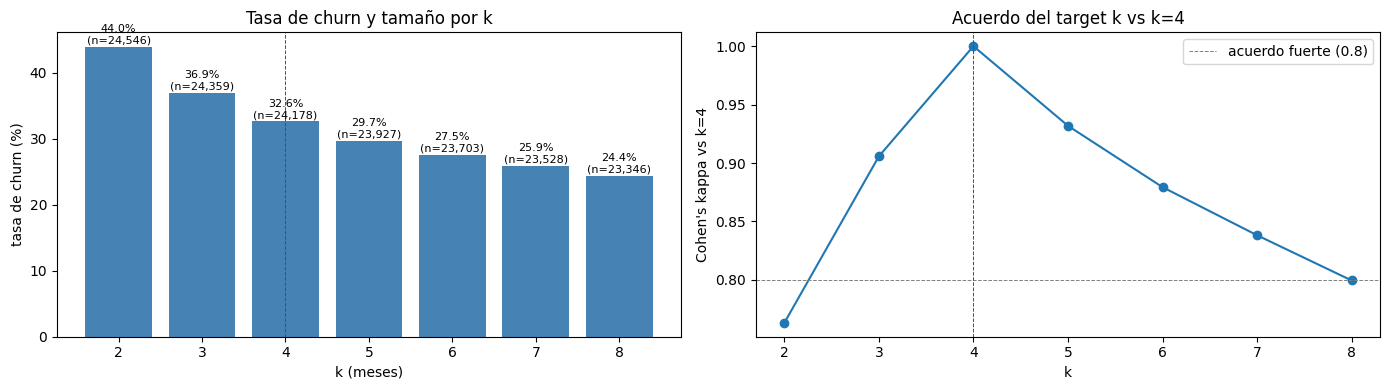

In [5]:
K_VALUES = [2, 3, 4, 5, 6, 7, 8]
K_REF = 4  # horizonte vigente en v4

rows_per_k = {}
rows = []
for k in K_VALUES:
    elig = events_h3[events_h3['observable_horizon'] >= k].copy()
    elig['churn_k'] = (elig['gap_to_next'].isna() | (elig['gap_to_next'] > k)).astype(int)
    rows_per_k[k] = elig
    rows.append({
        'k': k,
        'n_obs':         len(elig),
        'n_vendedoras':  elig['id_vendedor'].nunique(),
        'churn_rate':    elig['churn_k'].mean(),
        'positives':     int(elig['churn_k'].sum()),
    })
sensitivity = pd.DataFrame(rows)
print('Sensibilidad por k:')
print(sensitivity.assign(churn_rate=lambda d: (d['churn_rate']*100).round(2)))

ref = rows_per_k[K_REF][['id_vendedor', 'mes_rank', 'churn_k']].rename(columns={'churn_k': f'churn_{K_REF}'})
rows_kappa = []
for k in K_VALUES:
    if k == K_REF:
        rows_kappa.append({'k': k, 'kappa_vs_ref': 1.0, 'agree_pct': 1.0, 'n_overlap': len(ref)})
        continue
    cmp = (
        rows_per_k[k][['id_vendedor', 'mes_rank', 'churn_k']]
        .rename(columns={'churn_k': f'churn_{k}'})
        .merge(ref, on=['id_vendedor', 'mes_rank'], how='inner')
    )
    if len(cmp) == 0:
        rows_kappa.append({'k': k, 'kappa_vs_ref': np.nan, 'agree_pct': np.nan, 'n_overlap': 0})
        continue
    rows_kappa.append({
        'k': k,
        'kappa_vs_ref': cohen_kappa_score(cmp[f'churn_{k}'], cmp[f'churn_{K_REF}']),
        'agree_pct':    (cmp[f'churn_{k}'] == cmp[f'churn_{K_REF}']).mean(),
        'n_overlap':    len(cmp),
    })
kappa = pd.DataFrame(rows_kappa)
print(f'\nConcordancia con churn (k={K_REF}):')
print(kappa.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(sensitivity['k'].astype(str), sensitivity['churn_rate'] * 100, color='steelblue')
for i, (k_, r_, n_) in enumerate(zip(sensitivity['k'], sensitivity['churn_rate'], sensitivity['n_obs'])):
    ax[0].text(i, r_ * 100 + 0.5, f'{r_:.1%}\n(n={n_:,})', ha='center', fontsize=8)
ax[0].axvline(K_VALUES.index(K_REF), ls='--', color='red', lw=0.7)
ax[0].set_xlabel('k (meses)')
ax[0].set_ylabel('tasa de churn (%)')
ax[0].set_title('Tasa de churn y tamaño por k')

ax[1].plot(kappa['k'], kappa['kappa_vs_ref'], marker='o')
ax[1].set_xlabel('k')
ax[1].set_ylabel(f'Cohen\'s kappa vs k={K_REF}')
ax[1].set_title(f'Acuerdo del target k vs k={K_REF}')
ax[1].axhline(0.8, ls='--', color='gray', lw=0.7, label='acuerdo fuerte (0.8)')
ax[1].axvline(K_REF, ls='--', color='red', lw=0.7)
ax[1].legend()
plt.tight_layout()
plt.show()

SENSITIVITY = sensitivity
KAPPA = kappa


**Insight — Sensibilidad y kappa**

- `churn_rate` por k muestra cuánto cambia la prevalencia con la elección
  del horizonte.
- Cohen's kappa contra k=4 mide cuánto se reetiquetaría el dataset si
  cambiamos. κ ≥ 0.9 = casi indistinguible; κ < 0.8 = cambio material.
- El target es robusto si los k vecinos a la referencia tienen κ alto.


## 5. Codo automático


In [6]:
rates = sensitivity.set_index('k')['churn_rate']
deltas = rates.diff(-1).abs()
print('Delta absoluta entre tasas consecutivas:')
print(deltas.round(4))

THRESHOLD_PP = 0.02
k_codo_candidates = deltas[deltas < THRESHOLD_PP].index.tolist()
k_codo = k_codo_candidates[0] if k_codo_candidates else int(rates.idxmin())
print(f'\nk recomendado por codo (Δtasa < {THRESHOLD_PP*100:.0f}pp): {k_codo}')
print(f'k vigente en v4: 4')

K_CODO = k_codo


Delta absoluta entre tasas consecutivas:
k
2    0.0702
3    0.0429
4    0.0297
5    0.0215
6    0.0161
7    0.0149
8       NaN
Name: churn_rate, dtype: float64

k recomendado por codo (Δtasa < 2pp): 6
k vigente en v4: 4


## 6. Cohortes pre-2025 vs post-2025


La motivación de v4 es el cambio de régimen 2025 (de 1 campaña/mes a 2-3).
Verificamos si el horizonte óptimo cambia entre cohortes — si difiere, la
elección debe favorecer al régimen actual.


           n_eventos  n_vendedoras    mes_min    mes_max
cohorte                                                 
post_2025       3034           956 2025-01-01 2026-04-01
pre_2025       21851          4037 2017-01-01 2024-12-01

Curva silent por cohorte:
cohorte  post_2025  pre_2025
k                           
1           0.6536    0.5839
2           0.4994    0.4364
3           0.4121    0.3666
4           0.3666    0.3249
5           0.3350    0.2965
6           0.3021    0.2751
7           0.2718    0.2595
8           0.2440    0.2450
9           0.2301    0.2337
10          0.2187    0.2256
11          0.2061    0.2169
12          0.1960    0.2095


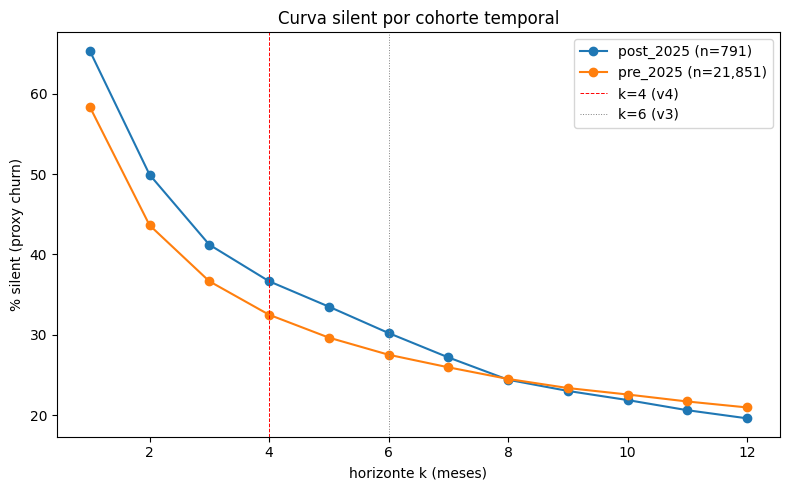


Sensibilidad por cohorte:
cohorte  post_2025  pre_2025
k                           
2           0.4649    0.4364
3           0.3927    0.3666
4           0.3404    0.3249
5           0.2991    0.2965
6           0.2754    0.2751
7           0.2534    0.2595
8           0.2314    0.2450


In [7]:
CUTOFF = pd.Timestamp('2025-01-01')

events_h3 = events_h3.assign(cohorte=np.where(events_h3['mes'] < CUTOFF, 'pre_2025', 'post_2025'))

cohorte_summary = (
    events_h3.groupby('cohorte')
    .agg(n_eventos=('mes_rank', 'size'),
         n_vendedoras=('id_vendedor', 'nunique'),
         mes_min=('mes', 'min'),
         mes_max=('mes', 'max'))
)
print(cohorte_summary)

rows = []
for cohorte, g in events_h3.groupby('cohorte'):
    sub = g[g['observable_horizon'] >= MAX_K]
    for k in range(1, MAX_K + 1):
        silent = (sub['gap_to_next'].isna() | (sub['gap_to_next'] > k)).mean()
        rows.append({'cohorte': cohorte, 'k': k, 'pct_silent': silent, 'n': len(sub)})
curve_cohort = pd.DataFrame(rows)
print('\nCurva silent por cohorte:')
print(curve_cohort.pivot(index='k', columns='cohorte', values='pct_silent').round(4))

fig, ax = plt.subplots(figsize=(8, 5))
for cohorte, sub in curve_cohort.groupby('cohorte'):
    n = sub['n'].iloc[0]
    ax.plot(sub['k'], sub['pct_silent'] * 100, marker='o', label=f'{cohorte} (n={n:,})')
ax.axvline(4, ls='--', color='red', lw=0.7, label='k=4 (v4)')
ax.axvline(6, ls=':',  color='gray', lw=0.7, label='k=6 (v3)')
ax.set_xlabel('horizonte k (meses)')
ax.set_ylabel('% silent (proxy churn)')
ax.set_title('Curva silent por cohorte temporal')
ax.legend()
plt.tight_layout()
plt.show()

# Sensibilidad por cohorte
rows = []
for cohorte, g in events_h3.groupby('cohorte'):
    for k in K_VALUES:
        elig = g[g['observable_horizon'] >= k]
        churn_k = (elig['gap_to_next'].isna() | (elig['gap_to_next'] > k)).astype(int)
        rows.append({'cohorte': cohorte, 'k': k,
                     'n_obs': len(elig),
                     'churn_rate': churn_k.mean()})
sens_cohort = pd.DataFrame(rows)
print('\nSensibilidad por cohorte:')
print(sens_cohort.pivot(index='k', columns='cohorte', values='churn_rate').round(4))

CURVE_COHORT = curve_cohort
SENS_COHORT  = sens_cohort


**Insight — Cohortes**

- Si la curva post_2025 cae más rápido que la pre_2025, las vendedoras del
  régimen actual vuelven antes → un k más corto sigue siendo apropiado.
- Si la post_2025 es más plana, aumenta la fracción de "silent legítimos" y
  un k corto inflaría falsos churn.
- La cohorte post_2025 tiene `observable_horizon` muy limitado (pocos meses
  desde 2025-01); leer la curva con cautela en k altos.


## 7. Síntesis y recomendación


In [8]:
print('=' * 70)
print('VALIDACIÓN DEL HORIZONTE — v4 mensual')
print('=' * 70)
print(f'\nDataset de eventos: {len(events):,} filas, '
      f'{events["id_vendedor"].nunique():,} vendedoras')
print(f'Filtro población   : cum_purchases >= 3')
print(f'Blacklist campañas : {BLACKLIST}')
print(f'k vigente en v4    : 4 meses')
print(f'k recomendado codo : {K_CODO} meses (Δtasa < 2pp)')

print('\n--- Stats de gaps ---')
for k_, v_ in GAP_STATS.items():
    print(f'  {k_:12s} = {v_:.4f}' if isinstance(v_, float) else f'  {k_:12s} = {v_}')

print('\n--- Sensibilidad ---')
print(SENSITIVITY[['k', 'n_obs', 'churn_rate']].assign(
    churn_rate=lambda d: (d['churn_rate']*100).round(2).astype(str) + '%'
).to_string(index=False))

print('\n--- Concordancia (kappa vs k=4) ---')
print(KAPPA.round(4).to_string(index=False))

print('\n--- Curva silent (global) ---')
print(HORIZON_CURVE.round(4).to_string(index=False))

print('\n--- Curva silent por cohorte ---')
print(CURVE_COHORT.pivot(index='k', columns='cohorte', values='pct_silent').round(4))

print('\n' + '=' * 70)
print('Decisión queda escrita en la celda markdown siguiente.')


VALIDACIÓN DEL HORIZONTE — v4 mensual

Dataset de eventos: 43,118 filas, 11,839 vendedoras
Filtro población   : cum_purchases >= 3
Blacklist campañas : (20102, 20201, 23105)
k vigente en v4    : 4 meses
k recomendado codo : 6 meses (Δtasa < 2pp)

--- Stats de gaps ---
  n_gaps       = 20597
  p50          = 2.0000
  p75          = 3.0000
  p90          = 9.0000
  pct_ge_3     = 0.3284
  pct_ge_4     = 0.2454
  pct_ge_5     = 0.1951
  pct_ge_6     = 0.1611

--- Sensibilidad ---
 k  n_obs churn_rate
 2  24546     43.95%
 3  24359     36.93%
 4  24178     32.64%
 5  23927     29.67%
 6  23703     27.52%
 7  23528     25.91%
 8  23346     24.41%

--- Concordancia (kappa vs k=4) ---
 k  kappa_vs_ref  agree_pct  n_overlap
 2        0.7632     0.8865      24178
 3        0.9057     0.9572      24178
 4        1.0000     1.0000      24178
 5        0.9318     0.9707      23927
 6        0.8794     0.9491      23703
 7        0.8382     0.9326      23528
 8        0.7995     0.9175      23346



### Decisión

**Recomendación: migrar `HORIZON_CHURN` de 4 → 6 meses.**

#### Evidencia

| k (meses) | churn rate | Δ vs k+1 | κ vs k=4 | % falsos churn (gaps ≥k que vuelven) |
|-----------|------------|----------|----------|--------------------------------------|
| 2 | 43.9% | 7.0pp | 0.76 | — |
| 3 | 36.9% | 4.3pp | 0.91 | 32.8% |
| **4 (v4 hoy)** | **32.6%** | **3.0pp** | **1.00** | **24.5%** |
| 5 | 29.7% | 2.2pp | 0.93 | 19.5% |
| **6 (recomendado)** | **27.5%** | **1.6pp** | **0.88** | **16.1%** |
| 7 | 25.9% | 1.5pp | 0.84 | ~12% |
| 8 | 24.4% | — | 0.80 | — |

- **Codo automático (Δtasa < 2pp)**: k=6. Coincide con la elección de v3
  (NB 01) — el cambio de granularidad campaña → mes no movió el codo.
- **Hazard de retorno** (cell 9): cae fuerte hasta k=5 (8.8%) y se aplana
  entre k=6 (7.3%) y k=7 (5.9%). Después de 6 meses sin compra, la
  probabilidad de retorno ya es marginal.
- **Falsos churn**: k=4 marca como churn ~24.5% de gaps que terminan en
  compra; k=6 baja eso a ~16.1% (≈8pp menos de ruido en el target).
- **Concordancia κ(k=4, k=6) = 0.88** → cambio moderado, ≈95% de las
  etiquetas se mantienen. No es un re-etiquetado masivo.
- **Cohortes pre-2025 vs post-2025** (cell 18): la diferencia se concentra
  en k bajos (k=4: 34.0% post vs 32.5% pre, +1.5pp). En k=6 ambas
  convergen (27.5% vs 27.5%) y en k=7-8 la post incluso está por debajo.
  → **El régimen 2025 no exige un horizonte más corto**; es la misma
  curva con leve corrimiento. La motivación original de v4 (campaña → mes)
  sigue válida, pero no la elección de k=4.

#### Trade-off vs k=5

k=5 es un compromiso razonable (Δ5→6 = 2.2pp queda apenas afuera del
threshold del codo). Si el negocio necesita una señal **más temprana**
para activar retención antes, k=5 da:
- churn rate 29.7% (vs 27.5% en k=6)
- κ=0.93 vs k=4 (más cercano al actual)
- ~19.5% falsos churn (vs 16.1% en k=6)

#### Decisión final

**Migrar a k=6** salvo que el equipo de retención necesite explícitamente
señal a 5 meses. Los argumentos:

1. **Consistencia metodológica**: el codo automático sigue en 6 (igual
   que v3). v4 cambió la unidad temporal, no la fenomenología del churn.
2. **Menos ruido en el target**: −8pp de falsos churn vs k=4.
3. **Robusto a cohortes**: pre/post-2025 convergen en k=6.
4. **Coste de migración bajo**: 3 cambios puntuales en
   `qry_churn_v4.sql` (header, CTE `target` con LEAD 1..6, CTE `panel`
   con `+ 6` en lugar de `+ 4`) y re-extraer la tabla.

#### Cambios en `qry_churn_v4.sql`

```sql
-- header
HORIZON_CHURN = 6 meses

-- CTE panel (línea 195)
AND m.mes_rank <= vv.ultima_compra_rank + 6   -- HORIZON_CHURN

-- CTE target (líneas 305-308)
LEAD(compro, 1) OVER w_fwd AS compro_t1,
LEAD(compro, 2) OVER w_fwd AS compro_t2,
LEAD(compro, 3) OVER w_fwd AS compro_t3,
LEAD(compro, 4) OVER w_fwd AS compro_t4,
LEAD(compro, 5) OVER w_fwd AS compro_t5,
LEAD(compro, 6) OVER w_fwd AS compro_t6

-- CTE ensamble (línea 393-401): suma t1..t6 en lugar de t1..t4
```

Después de re-extraer: re-correr NB 05 con la nueva tabla y verificar que
AUC y estabilidad temporal no se degraden (esperado: muy similar, dado
que κ=0.88 entre los dos targets).
